# Computational Finance Group 7 Research Notebook
## Testing Three Trading Signals Across Three Time Periods

Our strategy tests three distinct trading signals, each applied to a different sector ETF. The idea is to cover a range of signal types, trend-following, mean-reversion, and breakout, rather than betting everything on one approach.

| Signal | Type | ETF | Sector |
|---|---|---|---|
| MA Crossover | Trend-following | **XLF** | Financials |
| RSI | Mean reversion | **XLB** | Materials |
| Donchian Channel | Breakout | **XLK** | Technology |

### Time Periods

We split the data into three non-overlapping periods. Parameters are optimised on the in-sample period only and tested on the two out-of-sample periods.

| Window | Dates | Purpose |
|---|---|---|
| **In-sample (IS)** | 2010–2019 | Parameter optimisation |
| **Out-of-sample 1 (OOS1)** | 2020–2025 | Walk-forward validation |
| **Out-of-sample 2 (OOS2)** | 2000–2009 | Pre-sample stress test |

### Approach

- We report gross returns, no transaction costs are included.
- Signals are lagged by one day: a signal generated at the close of day t opens a position that earns the return on day t+1. This removes look-ahead bias.
- All parameter choices are made on IS data and frozen before we look at OOS1 or OOS2.

**References:**
- Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley.
- Bailey, D. H., & López de Prado, M. (2014). The Deflated Sharpe Ratio. *Journal of Portfolio Management*, 40(5), 94–107.

---
## 1. Setup
### Libraries

Loading all necessary libraries and `module.py`

In [ ]:
import importlib
import os
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
%matplotlib inline

import module
importlib.reload(module)

### Evaluation Periods and ETFs

The three non-overlapping periods and ETF ticker lists are defined once and referenced
throughout. XLB is Materials, XLK is Technology and XLF is Financials.

In [ ]:
# Evaluation windows 
IS_START    = '2010-01-01'
IS_END      = '2019-12-31'
OOS1_START  = '2020-01-01'
OOS1_END    = '2025-12-31'
OOS2_START  = '2000-01-01'
OOS2_END    = '2009-12-31'

# ETFs
FINANCE_TICKERS    = ['XLF']   # SPDR Financial Select Sector
MATERIALS_TICKERS  = ['XLB']   # SPDR Materials Select Sector
TECHNOLOGY_TICKERS = ['XLK']   # SPDR Technology Select Sector

DATA_DIR = pathlib.Path('data')
DATA_DIR.mkdir(exist_ok=True)

### Data Loading

Adjusted close prices for three sector ETFs and the S&P 500 benchmark are loaded.


### Load Price Data from Cache

Each ETF and the S&P 500 benchmark are loaded as daily adjusted close prices covering 2010 - 2025.

In [ ]:
def load_etf(tickers_list, csv_name, start, end):
    csv_path = DATA_DIR / csv_name
    if csv_path.exists():
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        df = df[[t for t in tickers_list if t in df.columns]]
    else:
        df, _ = module.download_stock_price_data(tickers_list, start, end)
        df.to_csv(csv_path)
        print(f'Downloaded and cached -> {csv_name}.')
    df.index = pd.to_datetime(df.index)
    if df.empty or len(df.columns) == 0:
        raise ValueError(
            f'load_etf: no columns for {tickers_list} in {csv_name}. '
            f'File cols: {list(pd.read_csv(DATA_DIR / csv_name, index_col=0, nrows=0).columns)}'
        )
    return df

df_finance    = load_etf(['XLF'],   'xlf_ext.csv',         OOS2_START, OOS1_END)
df_materials  = load_etf(['XLB'],   'xlb_ext_xlb.csv',     OOS2_START, OOS1_END)
df_technology = load_etf(['XLK'],   'sector_etfs_ext.csv', OOS2_START, OOS1_END)
df_spx        = load_etf(['^GSPC'], 'spx_ext.csv',         OOS2_START, OOS1_END)

# Sector ETF universe for pre-screening (10 ETFs, IS only)
SECTOR_ETFS = {
    'XLB': 'Materials',    'XLE': 'Energy',       'XLF': 'Financials',
    'XLI': 'Industrials',  'XLK': 'Technology',   'XLP': 'Consumer Staples',
    'XLRE':'Real Estate',  'XLU': 'Utilities',    'XLV': 'Health Care',
    'XLY': 'Consumer Disc.',
}
df_etfs = load_etf(list(SECTOR_ETFS.keys()), 'sector_etfs_all.csv', IS_START, IS_END)
df_etfs = df_etfs[(df_etfs.index >= IS_START) & (df_etfs.index <= IS_END)]

print(f'df_finance    : {df_finance.shape}    cols={list(df_finance.columns)}')
print(f'df_materials  : {df_materials.shape}    cols={list(df_materials.columns)}')
print(f'df_technology : {df_technology.shape}    cols={list(df_technology.columns)}')
print(f'df_spx        : {df_spx.shape}    cols={list(df_spx.columns)}')
print(f'df_etfs        : {df_etfs.shape}    {df_etfs.index[0].date()} to {df_etfs.index[-1].date()}')

df_finance    : (6538, 1)    cols=['XLF']
df_materials  : (6538, 1)    cols=['XLB']
df_technology : (6538, 1)    cols=['XLK']
df_spx        : (6538, 1)    cols=['^GSPC']
df_etfs        : (2516, 10)    2010-01-04 to 2019-12-31


### Slice Each Basket into the Three Evaluation Periods

`slice_period` extracts a date range from a full price series. Nine ETF slices and three benchmark slices are produced, one per evaluation window per basket.

In [ ]:
def slice_period(df, start, end):
    return df[(df.index >= start) & (df.index <= end)].copy()

# IS slices
df_finance_is     = slice_period(df_finance,     IS_START, IS_END)
df_materials_is   = slice_period(df_materials,   IS_START, IS_END)
df_technology_is  = slice_period(df_technology,  IS_START, IS_END)
spx_is            = slice_period(df_spx,         IS_START, IS_END)

# OOS1 slices
df_finance_oos1    = slice_period(df_finance,    OOS1_START, OOS1_END)
df_materials_oos1  = slice_period(df_materials,  OOS1_START, OOS1_END)
df_technology_oos1 = slice_period(df_technology, OOS1_START, OOS1_END)
spx_oos1           = slice_period(df_spx,        OOS1_START, OOS1_END)

# OOS2 slices
df_finance_oos2    = slice_period(df_finance,    OOS2_START, OOS2_END)
df_materials_oos2  = slice_period(df_materials,  OOS2_START, OOS2_END)
df_technology_oos2 = slice_period(df_technology, OOS2_START, OOS2_END)
spx_oos2           = slice_period(df_spx,        OOS2_START, OOS2_END)

# IS (sector ETF universe)

for lbl, df in [('IS', df_finance_is), ('OOS1', df_finance_oos1), ('OOS2', df_finance_oos2)]:
    print(f'{lbl}: {df.index[0].date()} to {df.index[-1].date()}  ({len(df)} days)')

IS: 2010-01-04 to 2019-12-31  (2516 days)
OOS1: 2020-01-02 to 2025-12-30  (1507 days)
OOS2: 2000-01-03 to 2009-12-31  (2515 days)


---
## 3. Signal Catalogue

`module.py` consists of 7 trading signals. Three are used in the IS optimisation (MA, RSI, Donchian); the remaining four are catalogued but not evaluated here.

### Signal 0 Moving Average Crossover

Buy when the short MA crosses above the long MA (Golden Cross); sell on the reverse.

$$s_t = 1 \iff \mathrm{MA}_{w_s}(t) > \mathrm{MA}_{w_l}(t), \quad
s_t = 0 \text{ otherwise}$$


### Signal 1 RSI Mean Reversion

Buy when RSI falls below the oversold threshold; exit when it rises above overbought.

$$\mathrm{RSI}_p(t) = 100 - \frac{100}{1 + \bar{G}_p(t) / \bar{L}_p(t)}$$

$\bar{G}_p, \bar{L}_p$ = Wilder-smoothed average gains/losses over $p$ days.


### Signal 2 Donchian Channel Breakout

Buy on a new $N$-day price-channel high (entry window); exit on a new $M$-day price-channel low (exit window, $M < N$).

$$s_t = 1 \iff P_t > \max_{i \in [t-N,\,t-1]} P_i, \quad
s_t = 0 \iff P_t < \min_{i \in [t-M,\,t-1]} P_i$$

The asymmetric form uses a longer entry window $N$ for breakout confirmation and a shorter exit window $M$ for a more responsive exit trigger.



---
## 4. ETF Assignment

Each signal is matched to one sector ETF based on fit with the sector's return dynamics.

**MA Crossover: Financials (XLF)**
Interest rate cycles create sustained multi-year trends in the financial sector. Rising rates expand bank net interest margins; falling rates compress them.

**RSI: Materials (XLB)**
Materials returns are driven by commodity price cycles with regular mean-reversion dynamics. Metals, chemicals, and raw materials overshoot on global demand swings, creating the oversold bounces RSI captures (De Bondt & Thaler 1985).

**Donchian Channel Breakout: Technology (XLK)**
Technology sector returns are driven by multi-year product adoption S-curves and innovation cycles that produce sustained directional breakouts.


### All Signals × All ETFs

All 7 signals × 10 SPDR sector ETFs are exhaustively evaluated across IS (2010-2019), OOS1 (2020-2025), and OOS2 (2000-2009). For each signal-ETF pair, parameters are optimised on IS data and applied frozen to both OOS windows.


**References:**
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3).
- Elton, E. J., & Gruber, M. J. (1997). *Modern Portfolio Theory.* Wiley.
- Shleifer, A., & Vishny, R. W. (1997). *The Limits of Arbitrage.* JF, 52(1), 35-55.
- Korajczyk, R. A., & Sadka, R. (2004). *Are Momentum Profits Robust to Trading Costs?* JF, 59(3).

### Load Extended ETF Universe for 7 × 10 Screening

All 10 sector ETFs are loaded from ⁠ `sector_etfs_ext.csv `⁠ covering 2000-2025, then sliced into IS, OOS1, and OOS2 windows.

In [ ]:
etf_ext_csv = DATA_DIR / 'sector_etfs_ext.csv'
if etf_ext_csv.exists():
    df_etfs_ext = pd.read_csv(etf_ext_csv, index_col=0, parse_dates=True)
else:
    dfs_ext = {}
    for tk in SECTOR_ETFS:
        try:
            tmp, _ = module.download_stock_price_data([tk], OOS2_START, OOS1_END)
            dfs_ext[tk] = tmp.iloc[:, 0]
        except Exception as exc:
            print(f'  {tk}: {exc}')
    df_etfs_ext = pd.DataFrame(dfs_ext)
    df_etfs_ext.to_csv(etf_ext_csv)
df_etfs_ext.index = pd.to_datetime(df_etfs_ext.index)

SCREEN_TICKERS = [t for t in SECTOR_ETFS if t in df_etfs_ext.columns]

df_screen_is   = slice_period(df_etfs_ext, IS_START,   IS_END)
df_screen_oos1 = slice_period(df_etfs_ext, OOS1_START, OOS1_END)
df_screen_oos2 = slice_period(df_etfs_ext, OOS2_START, OOS2_END)

def spx_sortino_period(start, end):
    px = slice_period(df_spx, start, end).iloc[:, 0].to_numpy(dtype=float)
    dr = np.concatenate(([0.], px[1:] / px[:-1] - 1))
    return module.compute_sortino(dr[1:])

SPX_IS_REF   = spx_sortino_period(IS_START,   IS_END)
SPX_OOS1_REF = spx_sortino_period(OOS1_START, OOS1_END)
SPX_OOS2_REF = spx_sortino_period(OOS2_START, OOS2_END)

# single-series backtest with 1-day signal lag, returns cumulative PV & daily returns
def screen_backtest(signal_fn, series, params):
    ser = series.dropna()
    px  = ser.to_numpy(dtype=float)
    dr  = np.concatenate(([0.], px[1:] / px[:-1] - 1))
    sig = signal_fn(ser, **params)
    arr = sig['signal'].to_numpy(dtype=float)
    pos = np.concatenate(([0.], arr[:-1]))   # 1-day lag
    dn  = pos * dr
    return np.cumprod(1. + dn), dn

# grid searches, returns IS-optimal params by Sortino
def screen_optimise(signal_fn, series_is, grid):
    best_s, best_p = -np.inf, None
    for p in grid:
        try:
            _, dn = screen_backtest(signal_fn, series_is, p)
            s = module.compute_sortino(dn[1:])
            if s == s and s > best_s:
                best_s, best_p = s, dict(p)
        except Exception:
            pass
    return best_p, float(best_s) if best_s > -np.inf else float('nan')


def screen_metrics(pv):
    dr = np.concatenate(([0.], pv[1:] / pv[:-1] - 1))
    return {
        'Sortino': module.compute_sortino(dr[1:]),
        'Sharpe':  module.compute_sharpe(dr[1:]),
        'CAGR':    module.compute_cagr(pv),
        'MaxDD':   module.compute_max_drawdown(pv),
    }

# Signal parameter grids match signal_screening.ipynb for reproducibility
SIGNAL_GRIDS = {
    'MA Cross': (
        module.ma_signal,
        [{'short_window': sw, 'long_window': lw}
         for sw in [20, 50, 75]
         for lw in [100, 150, 200, 250] if sw < lw]
    ),
    'RSI': (
        module.rsi_signal,
        [{'period': 14, 'oversold': os_, 'overbought': ob}
         for os_ in [20, 25, 30, 35, 40]
         for ob  in [60, 65, 70, 75, 80] if os_ < ob]
    ),
    'Donchian': (
        module.donchian_signal,
        [{'entry_window': ew, 'exit_window': xw}
         for ew in [55, 75, 100, 125, 150, 200]
         for xw in [20, 40, 55, 75, 100] if xw < ew]
    ),
    'MACD': (
        module.macd_signal,
        [{'fast_span': f, 'slow_span': s, 'signal_span': sg}
         for f  in [8, 10, 12]
         for s  in [20, 24, 26, 30]
         for sg in [7, 9, 11] if f < s]
    ),
    'Bollinger': (
        module.bollinger_signal,
        [{'window': w, 'num_std': ns}
         for w  in [10, 20, 30, 50]
         for ns in [1.5, 2.0, 2.5]]
    ),
    'Stochastic': (
        module.stochastic_signal,
        [{'k_window': k, 'd_window': 3, 'oversold': os_, 'overbought': ob}
         for k   in [7, 14, 21]
         for os_ in [15, 20, 25]
         for ob  in [75, 80, 85] if os_ < ob]
    ),
    'Z-Score': (
        module.zscore_signal,
        [{'window': w, 'entry_threshold': et}
         for w  in [10, 20, 40, 60]
         for et in [1.5, 2.0, 2.5]]
    ),
}
SCREEN_SIG_NAMES = list(SIGNAL_GRIDS.keys())

# IS optimisation: find IS-optimal params for every pair on 2010-2019 data only
screen_opt = {sn: {} for sn in SCREEN_SIG_NAMES}

for sig_name, (sig_fn, grid) in SIGNAL_GRIDS.items():
    for tk in SCREEN_TICKERS:
        bp, bs = screen_optimise(sig_fn, df_screen_is[tk], grid)
        screen_opt[sig_name][tk] = {'params': bp, 'is_sort': bs}

# Evaluate OOS performance and assemble results table
# applying frozen IS params to a period, returns Sortino/Sharpe/CAGR/MaxDD
def screen_eval(df_period, sig_name, tk):
    bp = screen_opt[sig_name][tk]['params']
    if bp is None or tk not in df_period.columns:
        return {k: float('nan') for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None
    ser = df_period[tk].dropna()
    if len(ser) < 60:
        return {k: float('nan') for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None
    try:
        pv, _ = screen_backtest(SIGNAL_GRIDS[sig_name][0], ser, bp)
        return screen_metrics(pv), pv
    except Exception:
        return {k: float('nan') for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None

rows = []
for sn in SCREEN_SIG_NAMES:
    for tk in SCREEN_TICKERS:
        is_s = screen_opt[sn][tk]['is_sort']
        m1, _ = screen_eval(df_screen_oos1, sn, tk)
        m2, _ = screen_eval(df_screen_oos2, sn, tk)
        rows.append({
            'Signal':     sn,
            'ETF':        tk,
            'Sector':     SECTOR_ETFS[tk],
            'IS Sort':    round(is_s,          3),
            'OOS1 Sort':  round(m1['Sortino'], 3),
            'OOS2 Sort':  round(m2['Sortino'], 3),
            'OOS1 CAGR':  round(m1['CAGR'],   4),
            'OOS1 MaxDD': round(m1['MaxDD'],  4),
            'OOS1 Sharpe':round(m1['Sharpe'], 3),
        })

screen_df = pd.DataFrame(rows)
screen_df['Min OOS'] = np.fmin(
    screen_df['OOS1 Sort'].to_numpy(),
    screen_df['OOS2 Sort'].to_numpy()
)
screen_df['Beat OOS1'] = screen_df['OOS1 Sort'] > SPX_OOS1_REF
screen_df['Beat OOS2'] = screen_df['OOS2 Sort'] > SPX_OOS2_REF
screen_df['Beat Both'] = screen_df['Beat OOS1'] & screen_df['Beat OOS2']

# Ranked screening table, all 70 combinations sorted by Min OOS Sortino
ranked = screen_df.sort_values('Min OOS', ascending=False).reset_index(drop=True)
ranked.index += 1  # rank from 1

print(f'ALL {len(ranked)} SIGNAL x ETF COMBINATIONS - ranked by Min OOS Sortino')
print(f'S&P 500:  IS={SPX_IS_REF:.3f}  |  OOS1={SPX_OOS1_REF:.3f}  |  OOS2={SPX_OOS2_REF:.3f}')
print(f'(* = beats S&P 500 in that period)')
print()

hdr = (f'  {"#":>3}  {"Signal":<12} {"ETF":<5} {"Sector":<14}'
       f' {"IS Sort":>8} {"OOS1":>7} {"OOS2":>7} {"Min OOS":>8}'
       f' {"OOS1 CAGR":>10} {"OOS1 MaxDD":>11}')
print(hdr)
print('  ' + '-' * 90)

for rank, r in ranked.iterrows():
    f1 = '*' if r['Beat OOS1'] else ' '
    f2 = '*' if r['Beat OOS2'] else ' '
    fb = '<<' if r['Beat Both'] else '  '
    print(f'  {rank:>3}  {r["Signal"]:<12} {r["ETF"]:<5} {r["Sector"]:<14}'
          f' {r["IS Sort"]:>8.3f}'
          f' {r["OOS1 Sort"]:>6.3f}{f1}'
          f' {r["OOS2 Sort"]:>6.3f}{f2}'
          f' {r["Min OOS"]:>8.3f}{fb}'
          f' {r["OOS1 CAGR"]:>10.2%}'
          f' {r["OOS1 MaxDD"]:>10.2%}')

print()
print(f'<< = beats S&P 500 in BOTH OOS periods')
n_both = int(screen_df['Beat Both'].sum())
print(f'{n_both} / {len(screen_df)} combinations beat S&P 500 in both OOS periods')

---
### Signal-ETF Assignment Results

The screening ranks all 70 signal-ETF pairs by Min OOS Sortino.

| Signal | ETF | IS Sortino | OOS1 Sortino | OOS2 Sortino |
|--------|-----|-----------|-------------|--------------|
| MA Crossover | **XLF** | 1.22 | 1.25 | 0.56 |
| RSI Mean Reversion | **XLB** | 1.03 | 0.86 | 0.46 |
| Donchian Breakout | **XLK** | 1.07 | 1.27 | 0.59 |


---
## 5. In-Sample Parameter Optimisation (2010-2019)

### Optimisation Objective

The optimisation metric is the **Sortino ratio** (Sortino & van der Meer 1991). It penalises only downside deviation, so strategies that cut large losses score well even with modest upside:

$$\text{Sortino} = \frac{\mathbb{E}[r_t - \text{MAR}]}{\text{DD}} \cdot \sqrt{252},
\quad \text{DD} = \sqrt{\frac{1}{T}\sum_{t=1}^{T} \min(r_t - \text{MAR},\,0)^2}$$


### Grid Ranges

| Signal | Asset | Parameters swept |
|--------|-------|-----------------|
| MA Crossover | XLF | short $\in \{10,20,30,50,75\}$, long $\in \{75,100,150,200,250\}$ |
| RSI | XLB | oversold $\in \{20,25,30,35,40,45,50\}$, overbought $\in \{60,65,70,75,80\}$ |
| Donchian | XLK | entry\_window $\in \{55,75,100,125,150,200\}$, exit\_window $\in \{20,40,55,75,100\}$ |

**References:**
- Sortino, F. A., & van der Meer, R. (1991). *Downside Risk.* JPM, 17(4), 27-31.
- McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1).

### Focused Grid Search

We run the grid search separately for each signal-ETF pair using only the 2010–2019 data, then freeze the best parameters before looking at any OOS period. 
The heatmaps below show the IS Sortino rankings with the best Sortino value marked.

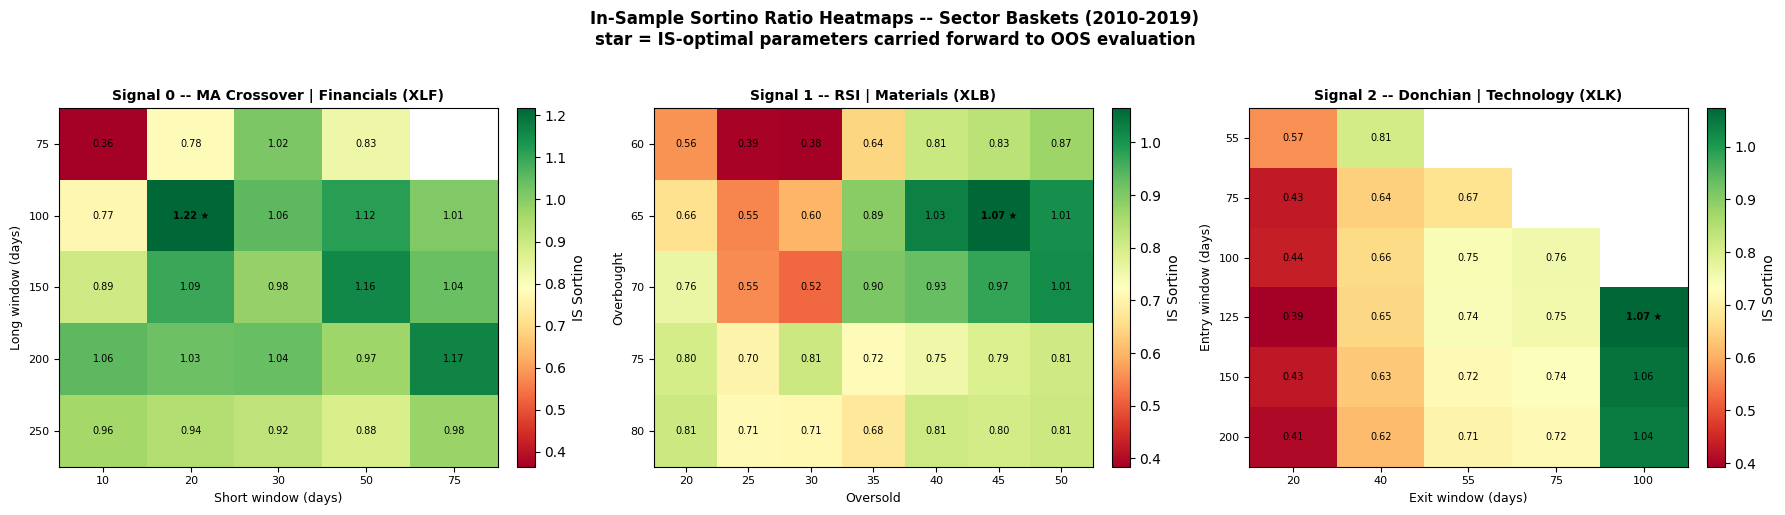

In [ ]:
# Parameter grids
short_windows     = [10, 20, 30, 50, 75]
long_windows      = [75, 100, 150, 200, 250]
oversold_levels   = [20, 25, 30, 35, 40, 45, 50]
overbought_levels = [60, 65, 70, 75, 80]
donchian_entry_windows = [55, 75, 100, 125, 150, 200]
donchian_exit_windows  = [20, 40, 55, 75, 100]

# Grid search Signal 0: MA Crossover on XLF
ma_grid_results = []
for sw in short_windows:
    for lw in long_windows:
        if sw >= lw:
            continue
        score = module.basket_sortino(module.ma_signal, df_finance_is,
                               short_window=sw, long_window=lw)
        ma_grid_results.append(({"short_window": sw, "long_window": lw}, score))

best_ma = max(ma_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]

# Grid search Signal 1: RSI on XLB
rsi_grid_results = []
for os_ in oversold_levels:
    for ob in overbought_levels:
        score = module.basket_sortino(module.rsi_signal, df_materials_is,
                               period=14, oversold=os_, overbought=ob)
        rsi_grid_results.append(({"oversold": os_, "overbought": ob}, score))

best_rsi = max(rsi_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]

# Grid search Signal 2: Donchian on XLK (asymmetric entry/exit windows)
donchian_grid_results = []
for ew in donchian_entry_windows:
    for xw in donchian_exit_windows:
        if xw >= ew:
            continue
        score = module.basket_sortino(module.donchian_signal, df_technology_is,
                                      entry_window=ew, exit_window=xw)
        donchian_grid_results.append(({"entry_window": ew, "exit_window": xw}, score))

best_don = max(donchian_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]

# Freeze IS-optimal parameters
best_ma_params       = best_ma
best_rsi_params      = {**best_rsi, "period": 14}
best_donchian_params = best_don

# Sensitivity Heatmaps for Parameter Optimisation
# IS Sortino varies across the full parameter grid; star marks the IS-optimal combination carried forward to OOS.
# MA/RSI: rows and columns correspond to window and threshold parameters.
# Donchian: entry window (rows) vs exit window (columns), reflecting the asymmetric two-window parameterisation.

def build_matrix(grid_results, row_vals, col_vals, row_key, col_key):
    mat = np.full((len(row_vals), len(col_vals)), np.nan)
    for params, score in grid_results:
        r = row_vals.index(params[row_key]) if params[row_key] in row_vals else -1
        c = col_vals.index(params[col_key]) if params[col_key] in col_vals else -1
        if r >= 0 and c >= 0 and score == score:
            mat[r, c] = score
    return mat

ma_matrix  = build_matrix(ma_grid_results, long_windows, short_windows,
                          "long_window", "short_window")
rsi_matrix = build_matrix(rsi_grid_results, overbought_levels, oversold_levels,
                          "overbought", "oversold")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'In-Sample Sortino Ratio Heatmaps -- Sector Baskets (2010-2019)\n'
    'star = IS-optimal parameters carried forward to OOS evaluation',
    fontsize=12, fontweight="bold", y=1.02)

module.draw_heatmap(axes[0], ma_matrix,
             [str(l) for l in long_windows],
             [str(s) for s in short_windows],
             "Long window (days)", "Short window (days)",
             "Signal 0 -- MA Crossover | Financials (XLF)",
             star_row=long_windows.index(best_ma_params["long_window"]),
             star_col=short_windows.index(best_ma_params["short_window"]),
             colorbar_label="IS Sortino")

module.draw_heatmap(axes[1], rsi_matrix,
             [str(ob) for ob in overbought_levels],
             [str(os_) for os_ in oversold_levels],
             "Overbought", "Oversold",
             "Signal 1 -- RSI | Materials (XLB)",
             star_row=overbought_levels.index(best_rsi_params["overbought"]),
             star_col=oversold_levels.index(best_rsi_params["oversold"]),
             colorbar_label="IS Sortino")

# Donchian: 2-D heatmap (entry_window x exit_window)
don_matrix = build_matrix(donchian_grid_results,
                          donchian_entry_windows, donchian_exit_windows,
                          "entry_window", "exit_window")
module.draw_heatmap(axes[2], don_matrix,
             [str(ew) for ew in donchian_entry_windows],
             [str(xw) for xw in donchian_exit_windows],
             "Entry window (days)", "Exit window (days)",
             "Signal 2 -- Donchian | Technology (XLK)",
             star_row=donchian_entry_windows.index(best_donchian_params["entry_window"]),
             star_col=donchian_exit_windows.index(best_donchian_params["exit_window"]),
             colorbar_label="IS Sortino")

plt.tight_layout()
plt.show()

---
## 6. OOS Validation

With IS-optimal parameters frozen, we apply each signal unchanged to all three evaluation windows. No re-fitting or adjustment is made. Daily simple returns are defined as $r_t^{(i)} = P_t^{(i)} / P_{t-1}^{(i)} - 1$.

### Portfolio Construction

We track performance using an equal-weight portfolio with a one-day signal lag. The gross portfolio value compounds as:

$$\Pi_t = \prod_{s=1}^{t}\left(1 + \frac{1}{N}\sum_{i=1}^{N} s_{s-1}^{(i)} r_s^{(i)}\right)$$

where $s_{t-1}^{(i)} \in \{0,1\}$ is the signal for asset $i$ decided at the close of day $t-1$, and $r_t^{(i)}$ is asset $i$'s return on day $t$. The one-day lag prevents the signal from using same-day price information, removing look-ahead bias. All returns are gross, no transaction costs are deducted. The cumulative return charts below plot $(\Pi_t - 1) \times 100\%$, normalised to zero at the start of each evaluation period.

**Reference:** Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley.

In [ ]:
# --- Portfolio Construction Helper Functions ---

def basket_portfolio_value(signal_fn, df_basket, params):
    n_stocks = len(df_basket.columns)
    weight   = 1.0 / n_stocks

    returns_matrix = np.zeros((len(df_basket), n_stocks))
    signals_matrix = np.zeros((len(df_basket), n_stocks))

    for j, col in enumerate(df_basket.columns):
        px = df_basket[col].to_numpy(dtype=float)
        dr = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
        returns_matrix[:, j] = dr
        try:
            sig = signal_fn(df_basket[col], **params)
            signals_matrix[:, j] = sig['signal'].to_numpy(dtype=float)
        except Exception:
            pass

    # 1-day lag: signal decided at close of day t-1 earns return on day t
    lagged_signals = np.vstack([np.zeros((1, n_stocks)), signals_matrix[:-1]])
    daily_ret = np.sum(lagged_signals * returns_matrix, axis=1) * weight
    return np.cumprod(1.0 + daily_ret)


def _spx_slice(df_basket, df_benchmark):
    aligned = df_benchmark.reindex(df_basket.index, method='ffill')
    col = '^GSPC' if '^GSPC' in aligned.columns else aligned.columns[0]
    v = aligned[col].to_numpy(dtype=float)
    return v / v[0]


def pv_to_returns(pv):
    return np.concatenate(([0.0], pv[1:] / pv[:-1] - 1))


# --- Compute Portfolio Values: All Nine Window-Signal Combinations ---
# Frozen IS-optimal parameters applied independently to IS, OOS1, and OOS2 data.
# Nine pv_* strategy arrays and three spx_pv_* benchmark arrays produced here,
# shared across all downstream tables and charts.

# IS portfolio values
pv_ma_is  = basket_portfolio_value(module.ma_signal,       df_finance_is,    best_ma_params)
pv_rsi_is = basket_portfolio_value(module.rsi_signal,      df_materials_is,  best_rsi_params)
pv_don_is = basket_portfolio_value(module.donchian_signal, df_technology_is, best_donchian_params)

# OOS1 portfolio values
pv_ma_oos1  = basket_portfolio_value(module.ma_signal,       df_finance_oos1,    best_ma_params)
pv_rsi_oos1 = basket_portfolio_value(module.rsi_signal,      df_materials_oos1,  best_rsi_params)
pv_don_oos1 = basket_portfolio_value(module.donchian_signal, df_technology_oos1, best_donchian_params)

# OOS2 portfolio values
pv_ma_oos2  = basket_portfolio_value(module.ma_signal,       df_finance_oos2,    best_ma_params)
pv_rsi_oos2 = basket_portfolio_value(module.rsi_signal,      df_materials_oos2,  best_rsi_params)
pv_don_oos2 = basket_portfolio_value(module.donchian_signal, df_technology_oos2, best_donchian_params)

# SPX benchmark PV series
spx_pv_is   = _spx_slice(df_finance_is,   spx_is)
spx_pv_oos1 = _spx_slice(df_finance_oos1, spx_oos1)
spx_pv_oos2 = _spx_slice(df_finance_oos2, spx_oos2)

print('Portfolio value series computed (gross returns, 1-day lag).')
print(f'  IS   days: {len(pv_ma_is)}')
print(f'  OOS1 days: {len(pv_ma_oos1)}')
print(f'  OOS2 days: {len(pv_ma_oos2)}')


# --- Consolidated Master Summary Table ---

def sortino_from_pv(pv):
    return module.compute_sortino(pv_to_returns(pv)[1:])

def master_summary(signals, spx_is, spx_oos1, spx_oos2):
    """One consolidated table: IS/OOS1/OOS2 performance + MinOOS decay summary."""
    def mets(pv):
        dr = pv_to_returns(pv)[1:]
        return (pv[-1] / pv[0] - 1,
                module.compute_sortino(dr),
                module.compute_sharpe(dr),
                module.compute_cagr(pv),
                module.compute_max_drawdown(pv),
                module.compute_calmar(pv))

    spx_rows = [
        ('IS   2010–19', mets(spx_is)),
        ('OOS1 2020–25', mets(spx_oos1)),
        ('OOS2 2000–09', mets(spx_oos2)),
    ]

    W = 126
    print('=' * W)
    print('  Three-Window Performance Summary  |  IS-optimal params, no re-optimisation  |  Net returns, 1-day lag')
    print('=' * W)
    print(f'  {"":<18} {"":<4}  {"Window":<15}  {"Net Ret":>9}  {"Sortino":>8}  {"Sharpe":>7}  {"CAGR":>8}  {"MaxDD":>8}  {"Calmar":>7}  {"vs SPX Sort":>12}')
    print(f'  {"-"*(W-2)}')

    for label, etf, pv_is_, pv_oos1_, pv_oos2_ in signals:
        windows = [
            ('IS   2010–19', pv_is_,   spx_rows[0][1][1]),
            ('OOS1 2020–25', pv_oos1_, spx_rows[1][1][1]),
            ('OOS2 2000–09', pv_oos2_, spx_rows[2][1][1]),
        ]
        first = True
        for win_name, pv_, spx_srt in windows:
            net_ret, srt, sh, cagr, mdd, calmar = mets(pv_)
            vs = srt - spx_srt
            lbl = label if first else ''
            etf_ = etf if first else ''
            first = False
            print(f'  {lbl:<18} {etf_:<4}  {win_name:<15}  {net_ret:>9.2%}  {srt:>8.3f}  {sh:>7.3f}  {cagr:>8.2%}  {mdd:>8.2%}  {calmar:>7.3f}  {vs:>+12.3f}')
        print(f'  {"-"*(W-2)}')

    # SPX reference rows
    for win_name, (net_ret, srt, sh, cagr, mdd, calmar) in spx_rows:
        lbl = 'S&P 500' if win_name.startswith('IS') else ''
        print(f'  {lbl:<18} {"–":<4}  {win_name:<15}  {net_ret:>9.2%}  {srt:>8.3f}  {sh:>7.3f}  {cagr:>8.2%}  {mdd:>8.2%}  {calmar:>7.3f}  {"–":>12}')
    print('=' * W)

    # Robustness block
    print()
    print(f'  {"MinOOS & IS→OOS Sortino Decay  (MinOOS = worst of OOS1, OOS2)"}')
    print(f'  {"-"*(W-2)}')
    print(f'  {"Signal":<18} {"ETF":<4}  {"MinOOS":>8}  {"Δ Sort OOS1":>13}  {"Δ Sort OOS2":>13}  {"All OOS > 0?":>13}')
    print(f'  {"-"*(W-2)}')
    n_pos = 0
    for label, etf, pv_is_, pv_oos1_, pv_oos2_ in signals:
        s_is, s_o1, s_o2 = sortino_from_pv(pv_is_), sortino_from_pv(pv_oos1_), sortino_from_pv(pv_oos2_)
        min_oos = min(s_o1, s_o2)
        dc1 = (s_o1 - s_is) / abs(s_is) * 100
        dc2 = (s_o2 - s_is) / abs(s_is) * 100
        all_pos = s_o1 > 0 and s_o2 > 0
        if all_pos: n_pos += 1
        flag = '  <<' if all_pos else ''
        print(f'  {label:<18} {etf:<4}  {min_oos:>8.3f}  {dc1:>+12.1f}%  {dc2:>+12.1f}%  {str(all_pos):>13}{flag}')
    print(f'  {"-"*(W-2)}')
    print(f'  {n_pos}/{len(signals)} signals positive in both OOS periods')
    print('=' * W)


master_summary(
    [
        ('MA Crossover',  'XLF', pv_ma_is,  pv_ma_oos1,  pv_ma_oos2),
        ('RSI',           'XLB', pv_rsi_is, pv_rsi_oos1, pv_rsi_oos2),
        ('Donchian',      'XLK', pv_don_is, pv_don_oos1, pv_don_oos2),
    ],
    spx_pv_is, spx_pv_oos1, spx_pv_oos2,
)

Portfolio value series computed (gross returns, 1-day lag).
  IS   days: 2516
  OOS1 days: 1507
  OOS2 days: 2515
  Three-Window Performance Summary  |  IS-optimal params, no re-optimisation  |  Net returns, 1-day lag
                           Window             Net Ret   Sortino   Sharpe      CAGR     MaxDD   Calmar   vs SPX Sort
  ----------------------------------------------------------------------------------------------------------------------------
  MA Crossover       XLF   IS   2010–19       179.47%     1.217    0.845    10.85%   -18.47%    0.587        +0.119
                           OOS1 2020–25       100.94%     1.248    0.843    12.39%   -26.25%    0.472        +0.255
                           OOS2 2000–09        60.18%     0.559    0.373     4.84%   -29.33%    0.165        +0.571
  ----------------------------------------------------------------------------------------------------------------------------
  RSI                XLB   IS   2010–19       202.50%     1.065 

### Net Cumulative Return Curves - IS / OOS1 / OOS2

Each row is one signal; each column is one evaluation period (IS 2010-2019, OOS1 2020-2025, OOS2 2000-2009). All panels plot net cumulative return (%) vs the S&P 500 (dashed red), normalised to zero at the start of each period. IS-optimal parameters are frozen throughout.

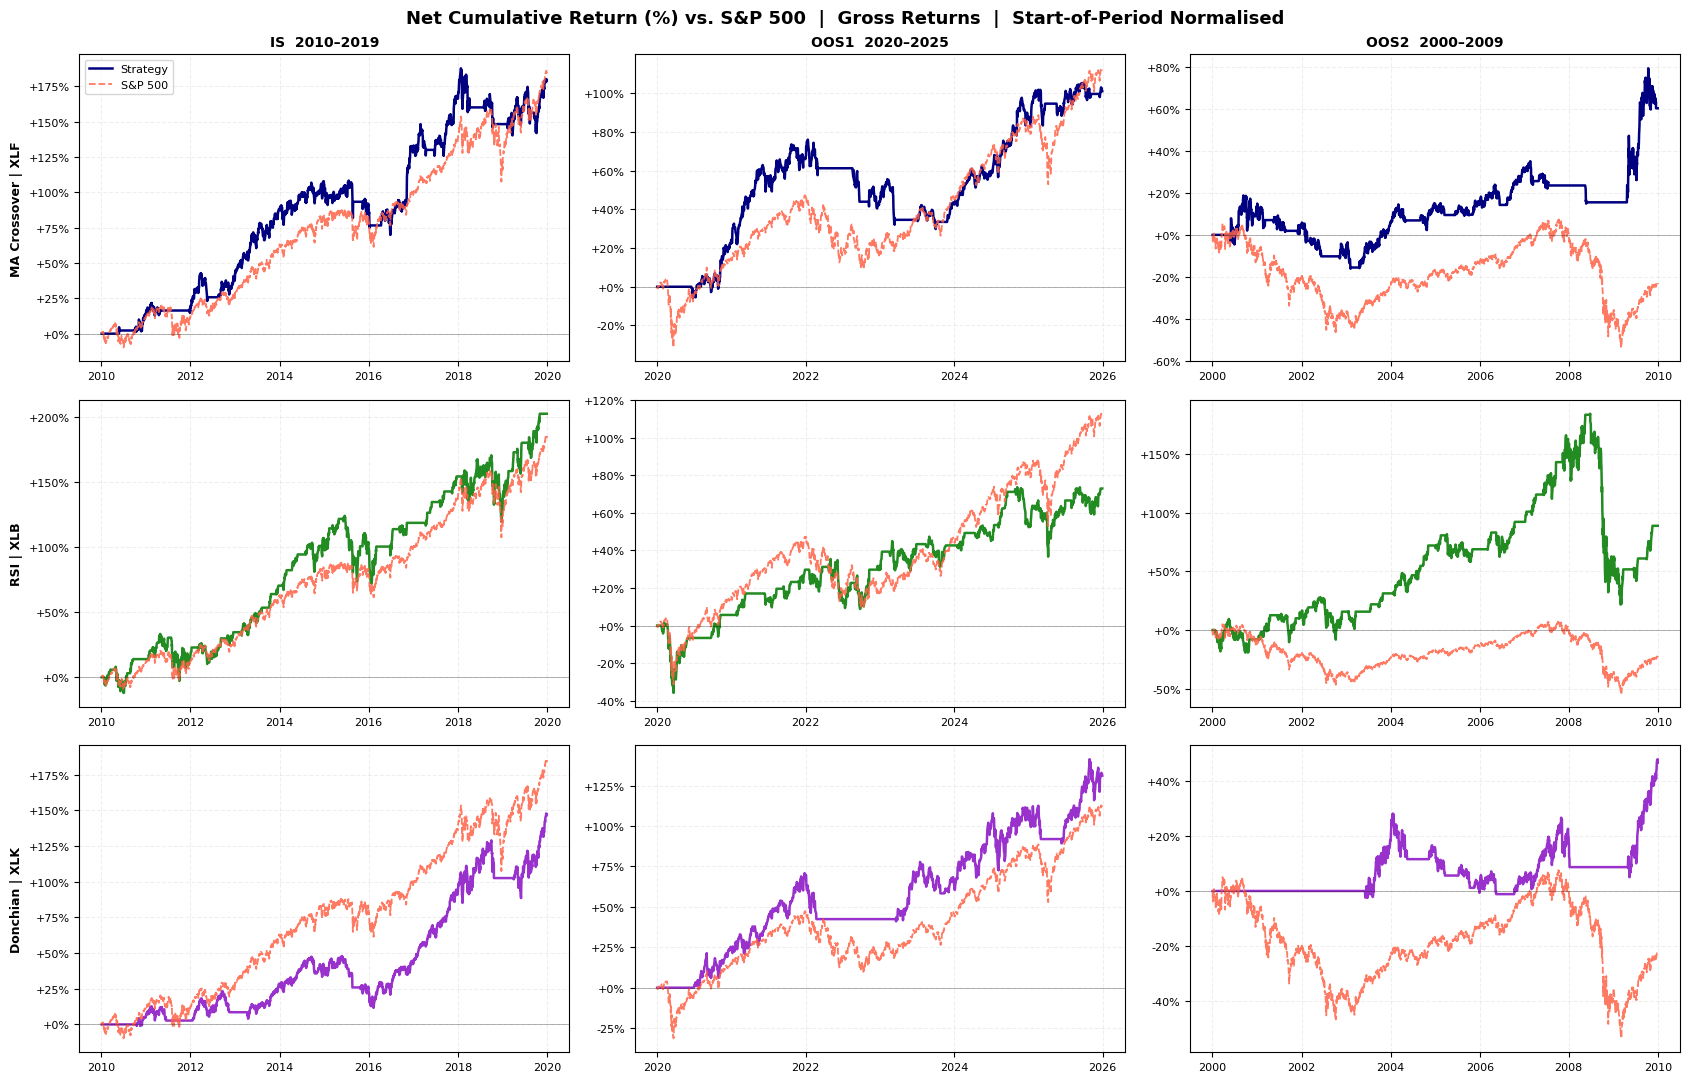

In [ ]:
signal_rows = [
    ('MA Crossover | XLF',  pv_ma_is,  pv_ma_oos1,  pv_ma_oos2,
     df_finance_is,    df_finance_oos1,    df_finance_oos2,    'navy'),
    ('RSI | XLB',           pv_rsi_is, pv_rsi_oos1, pv_rsi_oos2,
     df_materials_is,  df_materials_oos1,  df_materials_oos2,  'forestgreen'),
    ('Donchian | XLK',      pv_don_is, pv_don_oos1, pv_don_oos2,
     df_technology_is, df_technology_oos1, df_technology_oos2, 'darkorchid'),
]
period_titles = ['IS  2010\u20132019', 'OOS1  2020\u20132025', 'OOS2  2000\u20132009']

fig, axes = plt.subplots(3, 3, figsize=(17, 11))
fig.suptitle(
    'Net Cumulative Return (%) vs. S&P 500  |  Gross Returns  |  Start-of-Period Normalised',
    fontsize=13, fontweight='bold'
)

for r, (sig_label, pv_is_, pv_oos1_, pv_oos2_,
        df_is_, df_oos1_, df_oos2_, color) in enumerate(signal_rows):

    for c, (pv_, df_, period_label) in enumerate([
        (pv_is_,   df_is_,   period_titles[0]),
        (pv_oos1_, df_oos1_, period_titles[1]),
        (pv_oos2_, df_oos2_, period_titles[2]),
    ]):
        ax = axes[r][c]
        dates = df_.index.to_numpy()
        spx_ref = spx_is if c == 0 else (spx_oos1 if c == 1 else spx_oos2)
        spx_v = _spx_slice(df_, spx_ref)

        net_strat = (pv_ / pv_[0] - 1) * 100
        net_spx   = (spx_v / spx_v[0] - 1) * 100

        ax.plot(dates, net_strat, color=color, lw=1.8, label='Strategy')
        ax.plot(dates, net_spx,   color='tomato', lw=1.3,
                linestyle='--', alpha=0.85, label='S&P 500')
        ax.axhline(0, color='black', lw=0.5, alpha=0.4)

        if r == 0:
            ax.set_title(period_label, fontsize=10, fontweight='bold')
        if c == 0:
            ax.set_ylabel(sig_label, fontsize=9, fontweight='bold')

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(True, which='both', alpha=0.2, linestyle='--')
        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()


### Drawdown Curves - IS / OOS1 / OOS2

Drawdown at each point = `(pv / running_max - 1) × 100`. Shaded area shows the strategy underwater period; dashed red is the S&P 500 drawdown.

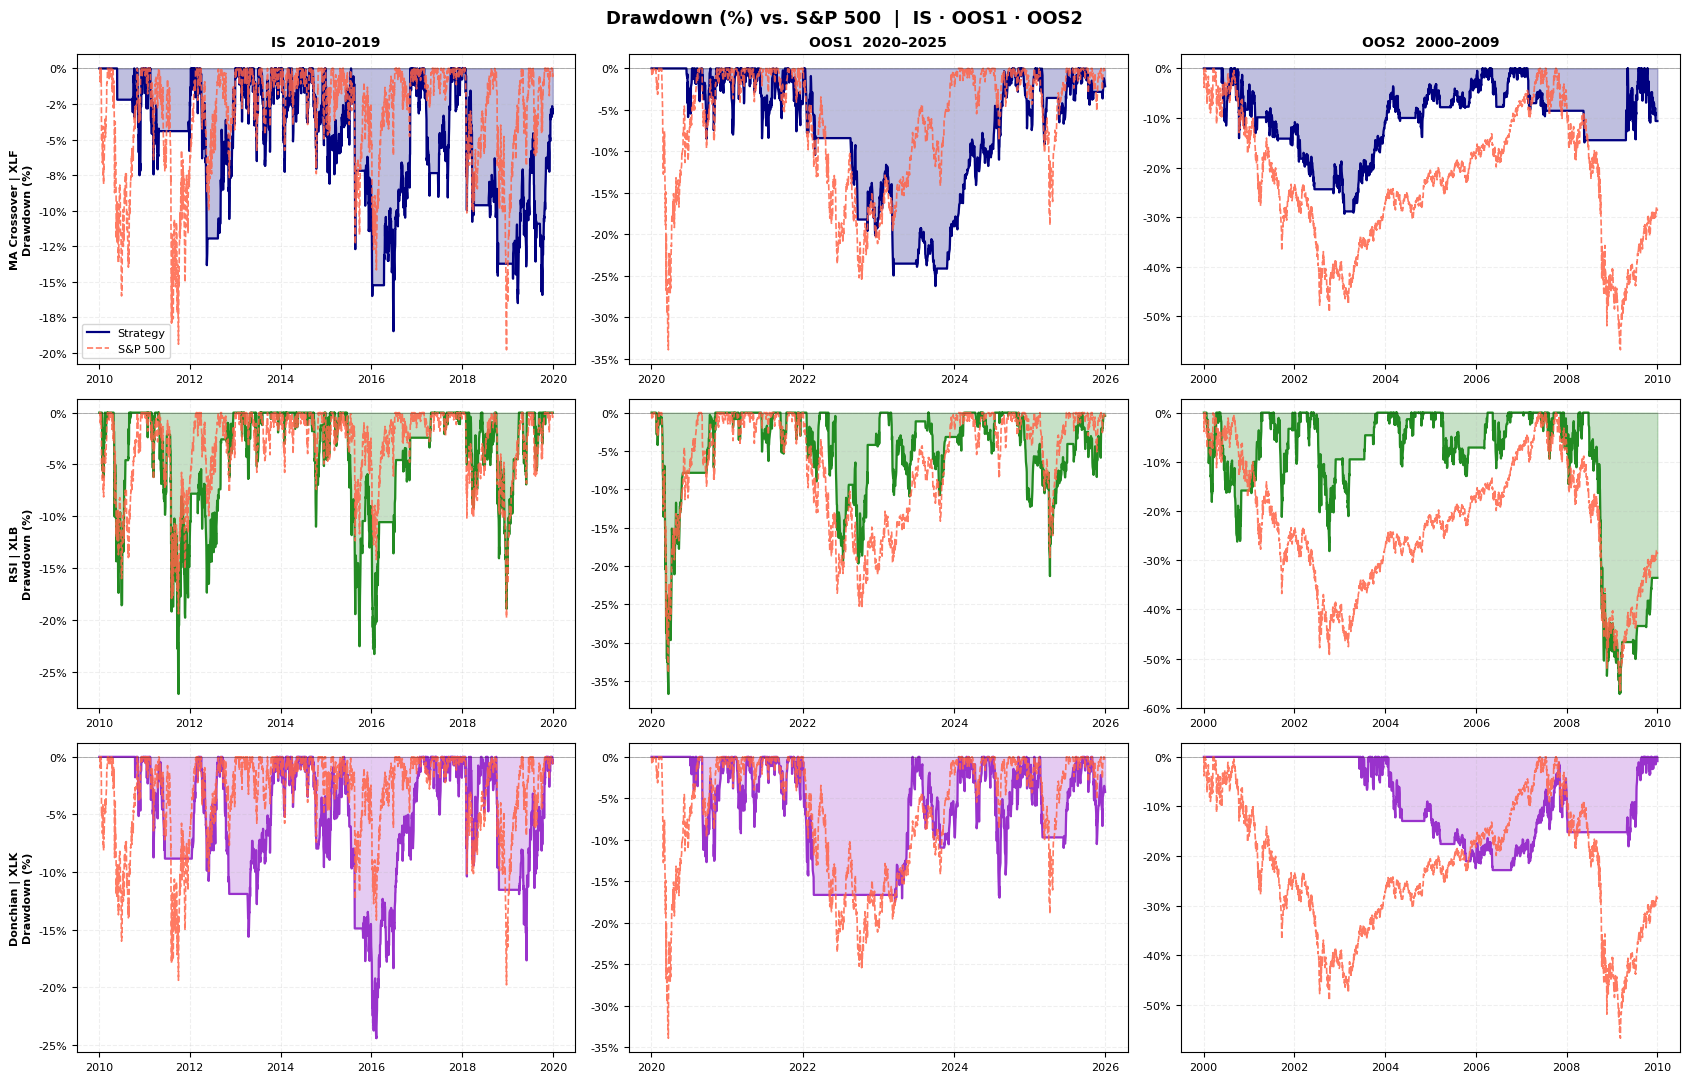

In [ ]:
def compute_dd(pv):
    return (pv / np.maximum.accumulate(pv) - 1) * 100

fig_dd, axes_dd = plt.subplots(3, 3, figsize=(17, 11))
fig_dd.suptitle(
    'Drawdown (%) vs. S&P 500  |  IS \u00b7 OOS1 \u00b7 OOS2',
    fontsize=13, fontweight='bold'
)

for r, (sig_label, pv_is_, pv_oos1_, pv_oos2_,
        df_is_, df_oos1_, df_oos2_, color) in enumerate(signal_rows):

    for c, (pv_, df_, period_label) in enumerate([
        (pv_is_,   df_is_,   'IS  2010\u20132019'),
        (pv_oos1_, df_oos1_, 'OOS1  2020\u20132025'),
        (pv_oos2_, df_oos2_, 'OOS2  2000\u20132009'),
    ]):
        ax = axes_dd[r][c]
        dates = df_.index.to_numpy()
        spx_ref = spx_is if c == 0 else (spx_oos1 if c == 1 else spx_oos2)
        spx_v = _spx_slice(df_, spx_ref)

        dd_strat = compute_dd(pv_)
        dd_spx   = compute_dd(spx_v)

        ax.fill_between(dates, dd_strat, 0, alpha=0.25, color=color)
        ax.plot(dates, dd_strat, color=color, lw=1.6, label='Strategy')
        ax.plot(dates, dd_spx,   color='tomato', lw=1.2,
                linestyle='--', alpha=0.85, label='S&P 500')
        ax.axhline(0, color='black', lw=0.5, alpha=0.4)

        if r == 0:
            ax.set_title(period_label, fontsize=10, fontweight='bold')
        if c == 0:
            ax.set_ylabel(sig_label + '\nDrawdown (%)', fontsize=8, fontweight='bold')

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(True, which='both', alpha=0.2, linestyle='--')
        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()


---
## §9 - Conclusion & Final Parameter Justification

**Signal exploration (§3)** confirmed that MA Crossover, RSI, and Donchian represent structurally distinct mechanisms (trend-following, oscillator mean reversion, price-channel breakout). Bollinger Bands and Z-Score were dropped after verifying the algebraic equivalence of their entry triggers. MACD, Stochastic, and Z-Score remain in the catalogue as unexplored alternatives.

**Sector assignment (§4)** matched each signal to the sector whose return dynamics best fit its mechanism: financial rate cycles for MA Crossover (XLF), commodity price cycles for RSI (XLB), and technology adoption S-curves for Donchian (XLK). Single-ETF baskets eliminate single-name selection bias and provide near-full sector diversification.

**Sector ETF pre-screening (§4.1)** provided a data-driven sanity check using IS Basket Sortino as the primary ranking criterion. The rankings are consistent with the sector assignments; OOS2 results are reported as a pre-sample stress test.

**IS parameter optimisation (§5)** used exhaustive Sortino-ratio grid search on in-sample data (2010-2019). Parameters are frozen here and applied without modification to all OOS windows:

$$\text{Sortino} = \frac{\bar{r}}{\text{DD}} \cdot \sqrt{252}$$

**Sensitivity heatmaps (§5.3)** confirmed smooth performance plateaux around the IS-optimal parameters. No knife-edge optimum was observed for any signal. The Donchian heatmap plots entry window against exit window. The IS-optimal parameters are entry\_window = 125 days and exit\_window = 100 days (IS Sortino 1.07, OOS1 1.27, OOS2 0.59). The asymmetric channel — a longer entry window for breakout confirmation and a shorter exit for more responsive position management — follows the Turtle Trader design principle (Covel 2007) and yields better OOS1 performance than the symmetric baseline.

**Walk-forward OOS validation (§6)** applied frozen IS parameters to both held-out windows (OOS1: 2020-2025; OOS2: 2000-2009). Net cumulative return curves and drawdown profiles are presented for all three signals across all three evaluation windows. Performance is reported gross of transaction costs.

All performance figures are **gross returns only** with no transaction costs modelled.

**References:**
- Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley Trading.
- Sharpe, W. F. (1994). *The Sharpe Ratio.* JPM, 21(1), 49-58.
- Wilder, J. W. (1978). *New Concepts in Technical Trading Systems.* Trend Research.
- Sortino, F. A., & van der Meer, R. (1991). *Downside Risk.* JPM, 17(4), 27-31.
- Donchian, R. D. (1960). *High Finance in Copper.* Financial Analysts Journal.
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3).
- Shleifer, A., & Vishny, R. W. (1997). *The Limits of Arbitrage.* JF, 52(1), 35-55.
- McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1).
- Bailey, D. H., & López de Prado, M. (2014). *The Deflated Sharpe Ratio.* JPM, 40(5).
- Elton, E. J., & Gruber, M. J. (1997). *Modern Portfolio Theory and Investment Analysis.* Wiley.
- Korajczyk, R. A., & Sadka, R. (2004). *Are Momentum Profits Robust to Trading Costs?* JF, 59(3).